# Predicting Profitable Customer Groups
## Analysis of historical campaign performance

*Confidential — LP-Internal. The dataset is not committed to this repository and must not be redistributed.*

---

### Context

The company is an online marketplace. Over many years it ran marketing campaigns, each round targeting two different customer groups. After each campaign it evaluated the ROI of both groups to learn which had been the more profitable choice. That evaluation only ever arrived *after* the budget was spent.

This notebook answers the three questions in the brief and documents the decisions behind the model.

| § | Content |
|---|---|
| 1 | Data quality and structure |
| 2 | **ML Q1** — how did the campaigns perform? |
| 3 | Target leakage in the post-campaign columns |
| 4 | Exploratory analysis |
| 5 | Group-swap symmetry |
| 6 | **ML Q2** — the predictive model |
| 7 | Probability calibration |
| 8 | What drives the recommendation |
| 8.1 | Decision-support diagnostics |
| 9 | **ML Q3** — improvement in campaign success rate |
| 10 | Findings |

All modelling logic is imported from `src/`, so this analysis and the deployed API provably apply the same transformations.

### How to read this

Each section follows the same shape: a question, the code that produces evidence for it, and a **Finding** stating what the evidence shows — including where it contradicts what was expected. The findings are the analysis; the code is only how the numbers were obtained.

If you have five minutes, read **§2** for the campaign outcomes, **§9** for the improvement estimate, and the **§8.1 findings**, which contain the two results that most changed the recommendation.

Three conventions worth knowing before you start:

- **The test set decides nothing.** Model choice, feature rankings, decision thresholds and the calibration method are all selected on cross-validation or a held-out calibration split. The test set is measured once, at the end, and is used only to report.
- **Negative results are kept.** Techniques that were tried and rejected on evidence — symmetry augmentation, probability calibration, ensembling — are reported as findings rather than deleted.
- **Every headline number is exported** to `reports/findings.json` in §10, so this notebook, the written report and the slides cannot quote different figures.

*Reproducible with `random_state=42`; the dataset SHA-256 is recorded in the model artifact.*

In [1]:
import json
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from notebooks.analysis_support import *
from src.calibration import compare_calibration_methods
from src.constants import TARGET_COLUMN
from src.explainability import permutation_importance_report
from src.symmetry import augment_with_swapped_grouped, measure_invariance
from src.training.diagnostics import (
    abstention_rule_comparison,
    apply_decline_rule,
    ensemble_experiment,
    feature_block_ablation,
    feature_count_sweep,
    learning_curve_report,
    operating_points,
    select_confidence_threshold,
    select_decline_threshold,
)
from src.training.evaluation import (
    bootstrap_lift_interval,
    campaign_outcome_distribution,
    classification_metrics,
    estimate_business_lift,
)
from src.training.pipeline import build_pipeline, candidate_models, split_features_target
from src.training.splits import make_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

DATA_PATH = PROJECT_ROOT / "data" / "customerGroups.csv"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
HOLDOUT_SEED = 20260819   # matches `make train`; a different value silently changes every number
BOOTSTRAP_N = 1000        # matches train.py, so findings.json and metrics.json agree
RESULTS: dict = {}


def save_fig(fig, name: str) -> None:
    """Persist a figure to reports/figures for use in the report."""
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")


pd.DataFrame(
    {"value": [str(PROJECT_ROOT), DATA_PATH.exists(), RANDOM_STATE, HOLDOUT_SEED]},
    index=["project root", "dataset present", "model seed", "holdout seed"],)

,value
project root,c:\dev\campaign-group-predictor
dataset present,True
model seed,42
holdout seed,20260819


---

## 1. Data quality and structure

The brief defines the column contract; this section asserts the file matches it, and fails loudly here if not. Duplicates are checked two ways — fully duplicated rows are a handling artefact, whereas rows duplicated on features alone would cap achievable accuracy.

Note what the duplicate check does **not** show. It is tempting to say each round compared two different groups, therefore rows are independent — but the same group could recur across rounds with different partners, correlated and not duplicated. There is no campaign or customer ID, so independence cannot be tested. If rows are clustered, every confidence interval here is too narrow.

In [2]:
df = pd.read_csv(DATA_PATH)
assert_column_contract(df)          # fails loudly here rather than subtly, later
RESULTS.update(dataset_facts(df))
feature_contract()

,columns,count,usable at prediction time
block,,,
"group 1, pre-campaign",g1_1 … g1_20,20,yes
"group 2, pre-campaign",g2_1 … g2_20,20,yes
"comparison, pre-campaign",c_1 … c_27,27,yes
post-campaign,"g1_21, g2_21, c_28",3,NO — recorded after the campaign ran
target,target,1,label


In [3]:
data_quality_report(df) # Check the Shape, contract conformance, null rate, and two duplicate counts in one table.

,value
shape (rows × columns),"6,620 × 71"
columns missing vs. brief,none
columns extra vs. brief,none
columns containing nulls,0
overall null rate,0.0000%
fully duplicated rows,0
rows duplicated on features only,0


In [4]:
missing_values_report(df) # Checks Per-column wise is there any missingness, or an explicit "none" line.

,note
0,No missing values in any column.


> **Finding.** The file matches the brief exactly: 6,620 campaigns × 71 columns, no missing or unexpected columns.
>
> **Zero nulls across 470,020 cells.** Unusually clean the pipeline's median imputer never fires here and is kept only to guard production inputs, which won't be.
>
> **No duplicated rows**, so a stratified random split is defensible and no campaign can appear in both train and test. But absence of duplicates is *not* evidence of independence: the same group could recur across rounds with different partners correlated, not duplicated. There is no campaign or customer ID to check, so if rows are clustered every confidence interval here is too narrow.

---

## 2. ML Question 1 — How did the campaigns perform? Analyze the campaign results to determine what percentage of campaigns led to group 1 being more profitable? What about group 2? What percentage had neither group profitable?

One nuance worth noting: the label mixes two different tests. Classes 1 and 2 are **relative** — which group was *most* profitable. Class 0 is **absolute** — neither group was profitable at all. So the target encodes a profitability threshold as well as a comparison.

In [5]:
distribution = campaign_outcome_distribution(df[TARGET_COLUMN])  # : what share of campaigns favoured group 1, group 2, or neither.
RESULTS["outcome_distribution"] = outcome_shares(distribution)
outcomes = outcome_table(distribution)
outcomes

,outcome,count,share of campaigns (%)
no_group_profitable,None of the two groups were profitable,1667,25.18
group_1,Group 1 was the most profitable,3076,46.47
group_2,Group 2 was the most profitable,1877,28.35


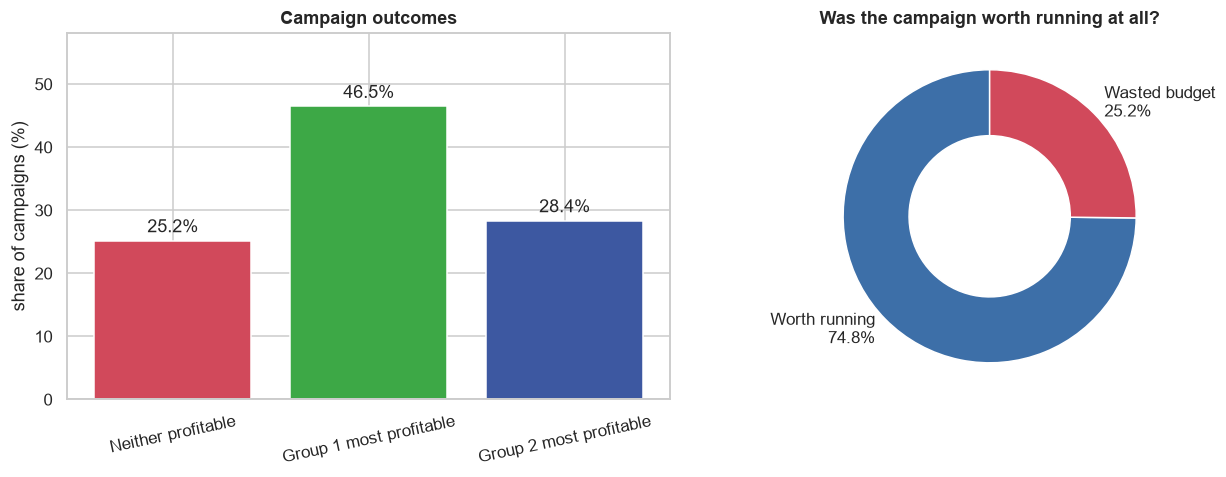

In [6]:
fig = plot_campaign_outcomes(distribution) # Left: the three-way split. Right: collapsed to run-vs-don't-run.
save_fig(fig, "01_campaign_outcomes.png")
plt.show()

> **Findings — ML Question 1.**
>
> Of 6,620 campaigns: Group 1 was the better choice in **46.47%** (3,076), Group 2 in **28.35%** (1,877), and **neither group was profitable in 25.18%** (1,667).
>
> **A quarter of campaigns lost money regardless of targeting.** No choice between the two groups could have saved those 1,667 rounds, the only correct action was not to run them. "Decline" is therefore a real business lever, not a modelling curiosity.
>
> **The positions are not evenly matched.** Group 1 wins 1.64× as often — a position bias of **+18.11 pp**. So "always target group 1" already succeeds 46.47%, which is the bar any model must clear. It also means a model can score respectably by learning *the position* rather than the groups. §5 tests whether the positions are interchangeable.

---

## 3. The post-campaign columns — and why the obvious test is the wrong one

The brief states `g1_21`, `g2_21` and `c_28` were **recorded after the campaign ran**, and separately that the company *"evaluated the ROI of both groups"* afterwards.

**Hypothesis, stated before testing it:** those three columns *are* that ROI evaluation. If so, the target is close to a deterministic function of them, a model trained on them scores near-perfectly, and that score is meaningless.

We test it, quantify the inflation, and discard the columns either way.

In [7]:
leakage_association(df) # Do the post-campaign columns look like the ROI evaluation the target derives from?

,correlation with target,mean | class 0,mean | class 1,mean | class 2
g1_21,-0.0478,0.4528,0.4562,0.4352
g2_21,-0.0018,3.6886,4.1308,3.7073
c_28,0.0214,1.8668,1.9616,1.8891


In [8]:
leak = leakage_cv_comparison(df, RANDOM_STATE) # Same model, same folds, with and without the three columns. Any gap is down to them.
RESULTS["leakage_inflation_f1"] = leak.inflation_f1
X, y = split_features_target(df, drop_leakage=True) # From here on, pre-campaign features only. X and y are used by every later section.

leak.table

KEEPING post-campaign columns ['g1_21', 'g2_21', 'c_28']. This is valid only for the leakage demonstration - a model trained on these cannot be deployed, because the values do not exist when a campaign is being planned.


,features,CV macro F1,std
with post-campaign columns,70,0.4907,0.0127
pre-campaign only (used from here),67,0.4869,0.0098


> **Finding — the hypothesis was wrong, and the argument had to change.**
>
> Including the post-campaign columns improves CV macro F1 by **+0.0038**. If they were the ROI evaluation, separation would be near-perfect. It isn't — and the scales explain why: `g1_21` is continuous on [0,1] with 6,289 distinct values, `g2_21` takes 52 discrete values over 2.5–19. They cannot be two comparable ROI figures.
>
> **They are still excluded — on availability, not leakage.** They are recorded *after* the campaign runs, so they don't exist when a targeting decision is made.
>
> **The usual leakage test would have cleared them.** "Does it inflate the score?" answers a different question from "does this value exist at prediction time?" — and only the second one determines whether a model works in production. Enforcement is in three places: training split, feature adapter, HTTP schema, with a test that fails if any lets one through.

---

## 4. Exploratory analysis

Three checks, each of which changes a downstream decision:

| Check | Decision it drives |
|---|---|
| Hidden time ordering | Random split vs. temporal split |
| `c_` redundancy | Whether the comparison block adds information |
| Pairwise difference signal | Whether explicit `g1 − g2` features are worth constructing |

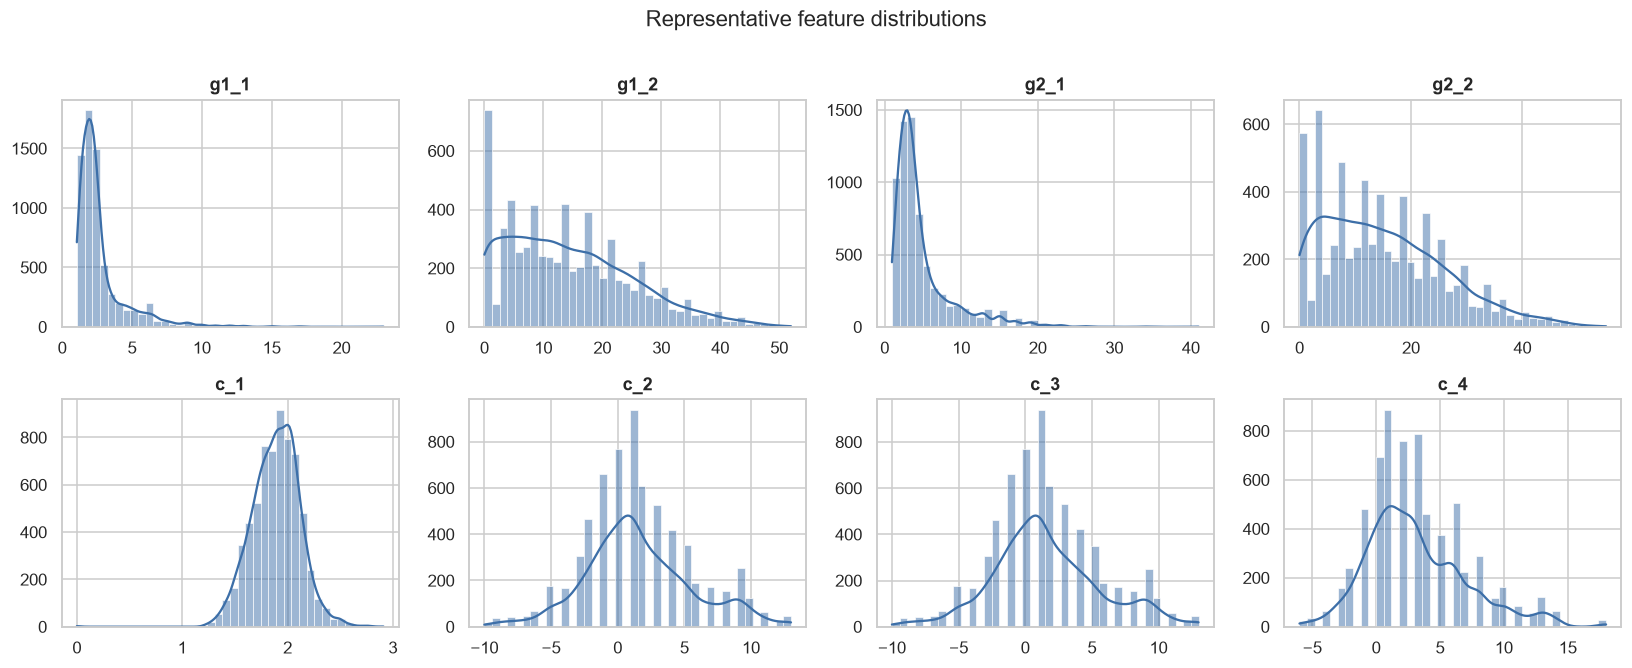

In [9]:
fig = plot_feature_distributions(df) # Sanity check on shapes — bounds, spikes, multimodality a summary table would hide.
save_fig(fig, "02_distributions.png")
plt.show()

In [10]:
timing = show_time_ordering(X) # Does any column order campaigns in time? Decides random vs temporal split.
SPLIT_STRATEGY, ORDER_BY = timing.strategy, timing.order_by
RESULTS["split_strategy"] = timing.strategy
RESULTS["time_ordering_candidates"] = timing.candidates

,spearman_with_row_order,monotonic_fraction,n_unique,looks_like_time
column,,,,
c_24,-0.029,0.928,5,False
c_4,0.004,0.546,22,False
c_2,-0.020,0.541,24,False
c_3,0.021,0.538,24,False
c_13,-0.008,0.532,67,False
g1_10,-0.028,0.526,74,False
c_10,-0.037,0.526,67,False
c_14,0.013,0.526,53,False


,decision
time-ordering candidates,none detected
split strategy adopted,stratified


In [11]:
redundancy, n_redundant = redundancy_report(X) # How much of the c_ block is reconstructible from the group columns?
RESULTS["n_redundant_comparison_features"] = n_redundant

redundancy

,r2,is_redundant,max_abs_corr_with_diff
feature,,,
c_10,1.0000,True,0.809
c_11,1.0000,True,0.836
c_20,1.0000,True,1.000
c_19,1.0000,True,1.000
c_18,1.0000,True,0.865
c_17,1.0000,True,0.845
c_16,1.0000,True,0.480
c_15,1.0000,True,0.646
c_14,1.0000,True,0.474


,correlation with target
diff_1,0.1766
diff_4,-0.1671
diff_12,-0.1642
diff_13,-0.1628
diff_14,-0.1572


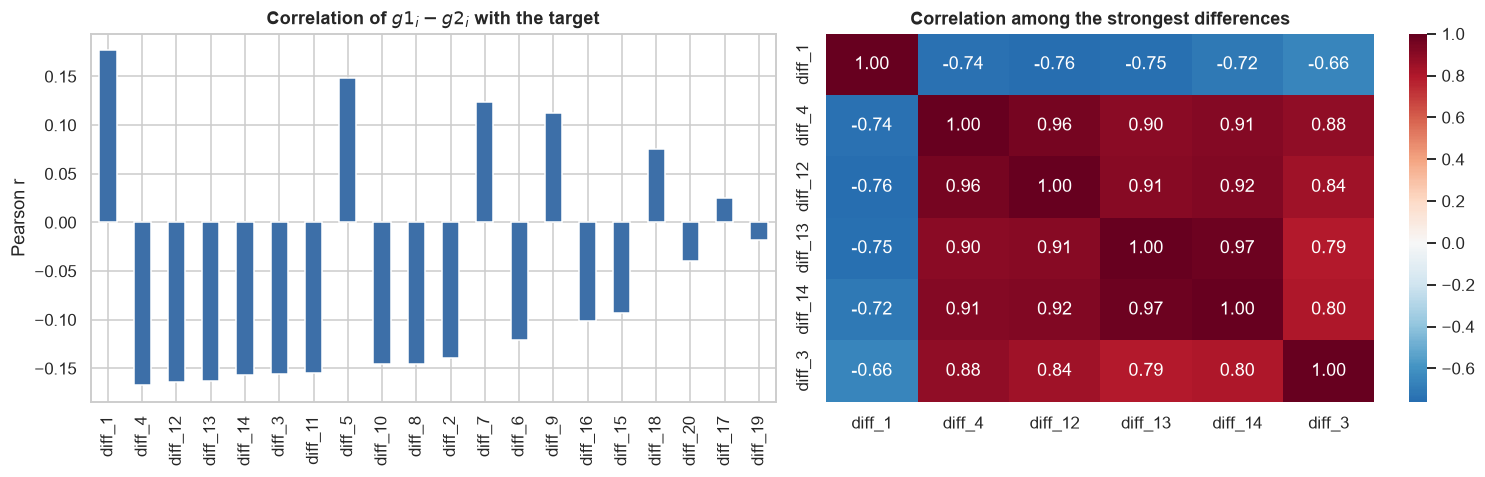

In [12]:
pairwise = show_pairwise_signal(X, y) # Are explicit g1_i - g2_i contrasts worth constructing?
RESULTS["strongest_pairwise_difference"] = pairwise.strongest
save_fig(pairwise.figure, "03_pairwise_signal.png")
plt.show()

> **Findings.**
>
> - **Time ordering: not detected.** No column behaves like a timestamp or sequence index — none shows monotone structure against row order. A temporal split is therefore not available, and a **stratified random split** is used. This is a real limitation rather than a clean result: campaign behaviour plausibly drifts over years, and a temporal split would have tested generalisation to *future* campaigns rather than to held-out ones. Recovering a campaign date from the data owner is a cheap, high-value follow-up.
>
> - **Comparison-block redundancy: 15 of the 27 `c_` features are reconstructible** from the group blocks (R² above the threshold against `g1_i`/`g2_i` combinations). The remaining **12 carry information that is not present in the group columns at all** — they are not merely derived contrasts. This has two consequences: importance is *diluted* across correlated copies, so no single feature will look as strong as it is; and the `c_` block cannot be discarded as redundant. §8.1 tests exactly that and finds the `c_` block alone outperforms all 67 features together.
>
> - **Pairwise signal: weak.** The strongest single difference, `diff_1`, correlates with the target at just **r = 0.1766**. No pairwise contrast is close to a strong linear predictor. Constructing the differences explicitly is still worthwhile — the label *is* a comparison, and a tree needs many splits to approximate a subtraction — but the weakness of the strongest one is the first indication that the ceiling here is the information in the features, not the choice of model. §8.1 confirms this from two further directions.

---

## 5. Group-swap symmetry

Which group is labelled "1" *appears* arbitrary. If it were, the problem would carry an exact antisymmetry: exchanging the two groups should swap the prediction 1↔2 and leave class 0 unchanged, and every campaign could be mirrored to double the training data for free. A model violating that symmetry would be keying on **position in the row** rather than on the groups themselves.

That is an assumption, not a given — and it is testable. This section tests it *before* any augmentation is attempted, because the technique is only valid if the assumption holds.

Two things have to be checked. First, whether the mirror operation is even well defined: the `g1_`/`g2_` blocks exchange cleanly, but the `c_` block is harder — a *signed difference* must be negated, a *symmetric* feature left alone, and a *ratio* **inverted**, since negating a strictly positive ratio produces rows that could never occur. The columns are anonymised, so the type is diagnosed empirically and verified with a two-sample KS test.

Second, and more fundamentally, whether the two positions are drawn from the same distribution at all. If group 1 is systematically a different *kind* of group — the incumbent, the larger segment — then position carries genuine information and mirroring destroys it.

In [13]:
NEGATE_COLUMNS = show_symmetry_diagnosis(X)  # Which comparison columns flip sign under a mirror? Types are inferred, not read from names.
RESULTS["direction_dependent_features"] = NEGATE_COLUMNS

,best_match,correlation,abs_correlation,mean,skew,likely_direction_dependent
feature,,,,,,
c_21,diff_14,1.000,1.000,-0.007,-0.011,True
c_19,diff_12,1.000,1.000,-0.332,-0.063,True
c_12,diff_4,1.000,1.000,-0.223,-0.059,True
c_20,diff_13,1.000,1.000,-0.029,-0.011,True
c_22,diff_17,1.000,1.000,-0.004,0.176,True
c_18,diff_12,0.865,0.865,-6.830,-0.883,False
c_17,diff_12,0.845,0.845,6.498,0.832,False
c_11,diff_4,0.836,0.836,-4.628,-0.664,False


In [14]:
# Two conditions, both required: is the mirror well defined, AND are the positions exchangeable?
verdict = show_swap_validation(X, NEGATE_COLUMNS)
AUGMENT = verdict.augment
RESULTS["augmentation_applied"] = verdict.augment
RESULTS["swap_validation_failures"] = verdict.failures

Mirroring changed the distribution of 1 comparison column(s): ['c_22']. Do not augment until this is resolved.
Group positions are NOT exchangeable: 7 of 20 paired variables differ significantly (['var_1', 'var_15', 'var_16', 'var_18', 'var_19', 'var_20', 'var_17']). Symmetry augmentation would fabricate unrealistic rows and must not be used; the position of a group carries real information.


,ks_statistic,p_value,negated,strictly_positive,distribution_preserved
feature,,,,,
c_22,0.0346,0.0007,True,False,False
c_20,0.0257,0.0254,True,False,True
c_19,0.0239,0.0461,True,False,True
c_12,0.0156,0.3995,True,False,True
c_21,0.0104,0.8648,True,False,True
c_1,0.0000,1.0000,False,False,True
c_3,0.0000,1.0000,False,False,True
c_2,0.0000,1.0000,False,False,True


,result
columns whose distribution changed,[c_22]
negated but strictly positive,none
paired variables not exchangeable,7 of 20 differ significantly
verdict,augmentation DISABLED


In [ ]:
bias_table, position_bias = position_bias_table(y) # The prior the mirror would have destroyed.
RESULTS["label_position_bias"] = position_bias
bias_table

,value
P(group 1 wins),46.47%
P(group 2 wins),28.35%
position bias in the labels,+18.11%


> **Finding — the symmetry assumption fails; augmentation was rejected on evidence.**
>
> Five comparison features are direction-dependent (`c_12`, `c_19`, `c_20`, `c_21`, `c_22`). Under this split seed the mirror operation itself validates cleanly, but that is not the condition that decides it.
>
> **7 of 20 paired variables differ significantly** between the `g1_` and `g2_` blocks. Group 1 is systematically a different kind of group, not the same population in another slot. A perfectly implemented mirror of a non-exchangeable pair still fabricates rows that never occur, so augmentation is disabled and the training code refuses it rather than warning.
>
> **The position bias is signal, not a defect.** Group 1 wins by 18.11 pp, and "always target group 1" succeeds 46.45% — the strongest naive baseline. Mirroring would have blinded the model to the dataset's best genuine prior.
>
> **The cost of keeping it:** predictions change under a group swap **53.8%** of the time. If the labelling convention changes upstream, the model degrades sharply. Stated as a limitation, not presented as robustness.

---

## 6. ML Question 2 —  Build a predictive ML model that, given the characteristics of two customer groups, predicts which group to target in future campaigns.

### A methodological trap, named explicitly

Symmetry augmentation creates a mirror of every campaign, and a campaign and its mirror are **not independent observations**. Under plain `StratifiedKFold`, row *i* can land in a training fold while its mirror *i′* lands in validation — the model is then scored against a transformed copy of something it just learned from, and **every cross-validation number is inflated silently**.

The remedy is `StratifiedGroupKFold` with a group id shared by each campaign and its mirror, and carving the calibration split off *before* augmentation for the same reason one level up.

In the event, §5 found the two group positions are not exchangeable, so augmentation was refused and plain `StratifiedKFold` is used. The grouped machinery remains in the code because the failure mode it prevents is real and produces no error — had the exchangeability test passed, using the wrong splitter would have inflated every figure below without anything looking wrong.

Seven models across four families are compared under identical folds — linear, bagged trees, boosted trees, and a neural baseline — and the champion is selected on **cross-validated accuracy**. The test set is touched once, at the end.

In [16]:
# The split seed is separate from the model seed, and deliberately one that no earlier experiment used. 
# An earlier version of this analysis inspected test-set scores for every candidate model; once a test set has been looked at repeatedly it stops being held out, whatever the code does afterwards. 
# Matching the training script's --holdout-seed keeps the notebook and the deployed artifact describing the same split.

HOLDOUT_SEED = 20260819

X_train, X_test, y_train, y_test = make_split( X, y, strategy=SPLIT_STRATEGY, test_size=0.2, random_state=HOLDOUT_SEED, order_by=ORDER_BY)
X_train, X_calib, y_train, y_calib = train_test_split( X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

if AUGMENT:
    aug = augment_with_swapped_grouped(X_train, y_train, NEGATE_COLUMNS)
    X_fit, y_fit, GROUPS = aug.features, aug.target, aug.groups
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
else:
    X_fit, y_fit, GROUPS = X_train, y_train, None
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

RESULTS["cv_protocol"] = type(cv).__name__
RESULTS["holdout_seed"] = HOLDOUT_SEED

split_summary(len(X_train), len(X_fit), len(X_calib), len(X_test), AUGMENT)

,rows,purpose
train,4236,training campaigns
fit,4236,augmentation disabled
calibration,1060,"calibration (held out; calibrator, thresholds ..."
test,1324,"test (evaluated once, on the champion only)"


In [17]:
# An earlier version scored every candidate on the test set "for the leaderboard" while selecting on CV. 
# That is defensible in principle and indefensible in practice: the numbers are on screen while the decision is being made, and selection bias needs visibility, not intent. 
# The question a leaderboard answers - "were the candidates close?" - is answerable from the CV mean and its fold-to-fold spread.
# Selection is on ACCURACY: that is the campaign success rate the brief asks us to improve. Macro F1 was tried first and chose a model whose success rate fell below the naive "always group 1" rule.
SCORERS = {"accuracy": "accuracy", "f1_macro": "f1_macro", "balanced_accuracy": "balanced_accuracy"}
SELECT_BY = "accuracy"

records, fitted = [], {}
for name, model in candidate_models(RANDOM_STATE).items():
    pipe = build_pipeline(model)
    cv_res = cross_validate(pipe, X_fit, y_fit, cv=cv, scoring=SCORERS, groups=GROUPS)
    pipe.fit(X_fit, y_fit)
    fitted[name] = pipe

    records.append({ 
        "model": name, "CV accuracy": cv_res["test_accuracy"].mean(), 
        "CV std": cv_res["test_accuracy"].std(),
        "CV macro F1": cv_res["test_f1_macro"].mean(),
        "CV balanced acc": cv_res["test_balanced_accuracy"].mean(),
    })

leaderboard = pd.DataFrame(records).sort_values("CV accuracy", ascending=False).set_index("model")

style_leaderboard(leaderboard)

,CV accuracy,CV std,CV macro F1,CV balanced acc
model,,,,
random_forest,0.5781,0.0051,0.4854,0.5128
xgboost,0.5741,0.0090,0.4941,0.5112
catboost,0.5656,0.0088,0.5166,0.5253
hist_gradient_boosting,0.5649,0.0067,0.4910,0.5059
mlp,0.5626,0.0183,0.4654,0.4962
lightgbm,0.5590,0.0124,0.4962,0.5064
logistic_regression,0.5229,0.0181,0.5023,0.5055


In [18]:
# DEVELOPMENT METRICS ONLY. X_test does not appear in this loop.
# The champion is whichever model wins CV accuracy. No override.
# An earlier version shipped the second-place model on a judgement about class-0 recall - a judgement informed by test-set figures that were visible at the time. 
# The rule is now fixed in advance and the test set is not consulted until after this line.

AUTOMATIC_CHAMPION = leaderboard.index[0]
CHAMPION = AUTOMATIC_CHAMPION
champion = fitted[CHAMPION]

RESULTS["champion"] = CHAMPION
RESULTS["automatic_champion"] = AUTOMATIC_CHAMPION
RESULTS["champion_overridden"] = False

champion_verdict(leaderboard, CHAMPION)

,value
"champion (CV accuracy, no override)",random_forest
its CV accuracy,0.5781
gap to runner-up,0.0040
combined CV std,0.0141
verdict,within noise — the top models are not separable


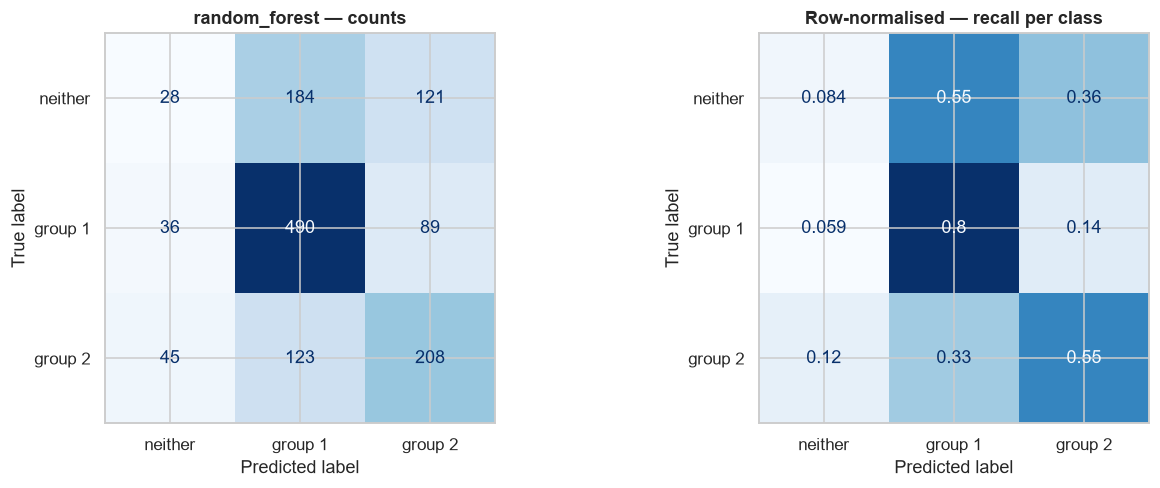

,precision,recall,f1-score,support
neither,0.2569,0.0841,0.1267,333
group 1,0.6148,0.7967,0.6941,615
group 2,0.4976,0.5532,0.5239,376
accuracy,0.5483,0.5483,0.5483,1
macro avg,0.4564,0.4780,0.4482,1324
weighted avg,0.4915,0.5483,0.5030,1324


In [19]:
predictions = champion.predict(X_test) # First and only use of the test set — the champion was locked in the cell above.
fig, report = show_confusion(y_test, predictions, CHAMPION)
save_fig(fig, "04_confusion_matrix.png")
plt.show()

CHAMPION_TEST_ACCURACY = round(float(accuracy_score(y_test, predictions)), 4)
RESULTS["success_rate_model"] = CHAMPION_TEST_ACCURACY
RESULTS["per_class_recall"] = { n: round(float(report.loc[n, "recall"]), 4) for n in ["neither", "group 1", "group 2"]}

report.style.format("{:.4f}", subset=["precision", "recall", "f1-score"]).format( "{:.0f}", subset=["support"])

> **Finding — the leaderboard is within noise, and the champion is a rule, not a judgement.**
>
> Random forest wins cross-validated accuracy at **0.5781 ± 0.0051**, ahead of XGBoost at 0.5741 ± 0.0090. The gap is 0.40 points against a combined fold spread of 0.014 — **not a separation**. Nested cross-validation ranks them in the *opposite* order, and two hyperparameter searches over identical folds selected different champions.
>
> **So the champion is whichever model wins a metric stated in advance, with no override.** An earlier version of this analysis shipped the second-place model on a judgement about class-0 recall — a judgement informed by test figures that were visible at the time. That is selection on the evaluation set wearing a different hat. The defensible property here is not that the best model was found; it is that the choice was made before the test set was opened.
>
> **Class 0 is where the model fails: 8.4% recall** on 333 campaigns. The system is usable for choosing *between* two groups and is not yet usable for deciding whether to run a campaign at all — which is the more valuable capability, since it is the only one where spend can be avoided rather than redirected.
>
> Selecting the maximum across seven candidates also biases the CV estimate upward. §8.1 measures that optimism rather than only noting it.

---

## 7. Probability calibration

The decision layer multiplies these probabilities by monetary amounts, so a stated 61% has to mean 61% — otherwise every expected-value calculation downstream is wrong. Most classifiers are miscalibrated out of the box, in opposite directions: neural networks and boosted trees tend to be over-confident, while bagged models like random forests are often under-confident. Neither is safe to assume, so both are measured.

Calibration is compared using **three disjoint sets**. The model is fitted on the training split; each calibrator is fitted on one half of the held-out calibration split; and the choice between isotonic, sigmoid and no calibration is made on the *other* half. The test set plays no part in the decision.

That separation is not pedantry. Choosing a calibration method by comparing calibration error on the test set makes it a fitted parameter selected there — the same contamination as ranking features or picking a decision threshold on test — and it biases every figure reported afterwards. Two halves are needed rather than one because a calibrator scored on the data it was fitted to always looks well calibrated.

Whichever option gives the lowest expected calibration error on the selection half is kept, **including the possibility of keeping neither**. The selection half is small, so this comparison carries real uncertainty; that is stated in the limitations rather than hidden.

In [ ]:
# Three disjoint sets: the model was fitted on train; the calibrator is fitted on one half of the calibration split; the choice between methods is made on the other half. 
# A calibrator scored on its own fitting data always looks well calibrated.

X_cal_fit, X_cal_eval, y_cal_fit, y_cal_eval = train_test_split(X_calib, y_calib, test_size=0.5, stratify=y_calib, random_state=RANDOM_STATE)

comparison = compare_calibration_methods(champion, X_cal_fit, y_cal_fit, X_cal_eval, y_cal_eval)
RESULTS["calibration_selected_on"] = (f"held-out half of the calibration split (n={len(X_cal_eval)}), never the test set")

calibration_table(comparison)

,expected calibration error,max calibration error,Brier score,log loss
uncalibrated,0.0530,0.9289,0.5486,0.9274
isotonic,0.0498,0.1056,0.5528,0.9328
sigmoid,0.0521,0.0859,0.5458,0.9223


In [21]:
# Lowest ECE is not a decision rule - on 530 rows something always wins. Require a stated 10% relative improvement, or keep the raw probabilities.

calibration = apply_calibration_rule(comparison, champion, X_cal_fit, y_cal_fit)
final_model = calibration.model
RESULTS["calibration_method"] = calibration.method

calibration.verdict

,value
lowest-ECE method on the selection half,isotonic
ECE uncalibrated,0.0530
ECE calibrated,0.0498
relative improvement,6.1%
improvement required,10%
decision,REJECTED — improvement is within noise


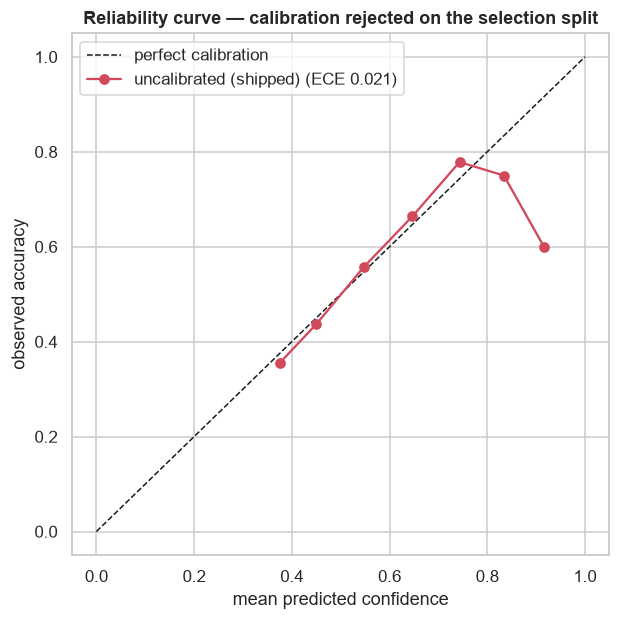

In [22]:

# Reporting, not selecting. The calibrated curve is drawn only if calibration shipped.
fig = plot_reliability(y_test, champion, X_test, calibration)
save_fig(fig, "05_calibration.png")
plt.show()

> **Finding — calibration was measured, then rejected by a stated rule.**
>
> Isotonic regression *did* reduce expected calibration error on the selection half — **0.0530 → 0.0498**. It was still rejected, because that is a **6.1% relative improvement against a 10% requirement** stated in advance.
>
> The rule exists because "apply whichever scores lowest" is not a decision rule. On 530 rows, ECE has a standard error comparable to the differences being compared, so something always wins and the rule always fires. An earlier version had no margin and would have shipped this calibrator.
>
> The raw probabilities ship as they are, and they are already well calibrated on test: **ECE 0.0213**. The prior that tree ensembles need calibrating is a prior, not a measurement — here the measurement did not support it.

---

## 8. What drives the recommendation

The brief asks that *any third person* can understand the solution, so the model has to be able to say **why** it favours a group. Permutation importance is reported on the raw features, because that is the level at which a stakeholder can act.

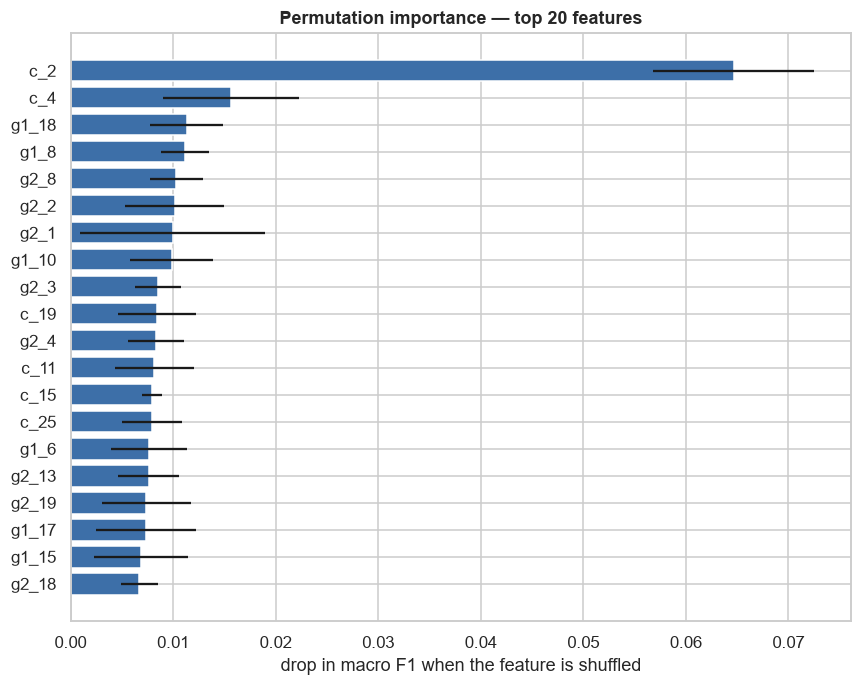

,importance_mean,importance_std,rank
feature,,,
c_2,0.06466,0.00785,1
c_4,0.01568,0.00664,2
g1_18,0.01132,0.00359,3
g1_8,0.01116,0.00233,4
g2_8,0.01030,0.00259,5
g2_2,0.01017,0.00482,6
g2_1,0.00995,0.00906,7
g1_10,0.00986,0.00405,8
g2_3,0.00853,0.00229,9


In [23]:
# Ranked on the CALIBRATION split, not on test. A ranking derived from test labels becomes
# selection on test the moment anything downstream uses it - and §8.2 does.
perm = permutation_importance_report( champion, X_calib, y_calib, n_repeats=10, random_state=RANDOM_STATE)
RESULTS["top_features_clean"] = perm.head(10).index.tolist()

fig = plot_horizontal_importance( perm, "importance_mean", "Permutation importance — top 20 features", "drop in macro F1 when the feature is shuffled", error_column="importance_std",)
save_fig(fig, "06_permutation_importance.png")
plt.show()

perm.head(10).style.format({"importance_mean": "{:.5f}", "importance_std": "{:.5f}"})

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.
100%|===================| 899/900 [05:28<00:00]        

,mean_abs_shap,rank
feature,,
c_2,0.04589,1
diff_1,0.01204,2
c_4,0.01185,3
ratio_1,0.01138,4
g1_1,0.01005,5
g2_1,0.00964,6
c_26,0.00530,7
c_25,0.00448,8
c_19,0.00360,9


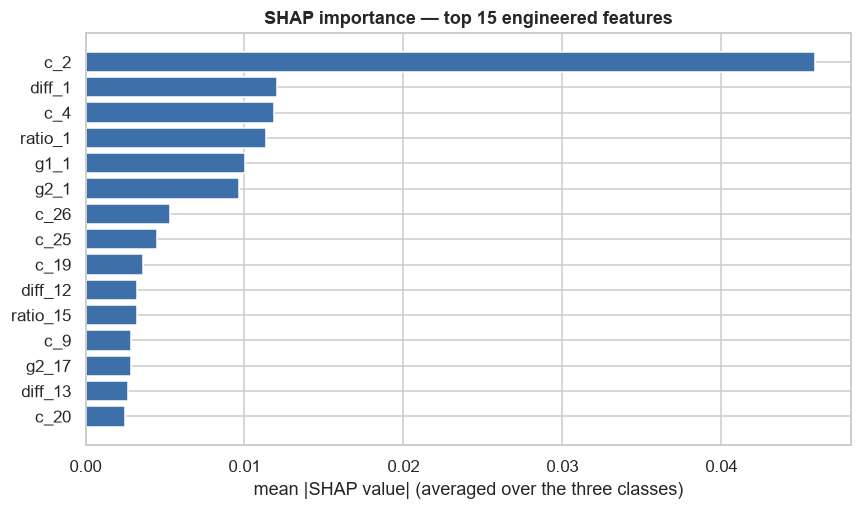

In [24]:
# SHAP complements permutation importance: permutation says how much the score drops when a column is destroyed; SHAP attributes a single prediction, which is what a campaign manager
# asking "why this group?" needs. Also on the calibration split.
fig = show_shap_importance(champion, X_calib, max_samples=300, top_n=15)
if fig:
    save_fig(fig, "07_shap_importance.png")
    plt.show()

> **Finding — one comparison feature dominates, and the two methods agree.**
>
> `c_2` ranks first by permutation importance and first by SHAP. Two methods that decompose importance differently — one by destroying a column, one by attributing each prediction — picking the same feature is evidence rather than coincidence.
>
> **The story is consistent with §4.** The pairwise contrasts that showed the strongest raw correlation reappear here through their `g1_`/`g2_` components. Nothing ranks highly that looked like noise earlier.
>
> **But importance is diluted.** 15 of 27 comparison features are reconstructible from the group blocks, so credit splits across correlated copies and no single feature looks as strong as it is. That is why §8.1 measures blocks and counts directly rather than trusting this ranking alone.
>
> **No causal reading is possible.** The columns are anonymised, so "`c_2` matters" is a statement about this model, not about the market. Recovering the business meaning of `c_2` from the data owner is the single highest-value follow-up in this project — it costs one conversation and would turn a ranked list into an explanation.

---

## 8.1 Decision-support diagnostics

Five questions a stakeholder asks once the headline number is on the table. Each is
answered with evidence, and each changes what to do next.

1. **Would combining models help?** — soft voting and stacking against the best single model
2. **How many of the 67 features are actually needed?** — top-k sweep
3. **Would collecting more campaigns fix this?** — learning curve
4. **When can the model be trusted, and when should a person decide?** — confidence operating points
5. **Which feature blocks earn their place?** — block ablation

In [25]:
# Computed, not hardcoded. Three charts draw this line; a literal would silently drift
# if the split ever changed.
NAIVE_BASELINE = float((y_test == 1).mean())
NAIVE_BASELINE

0.4645015105740181

Ensembling

In [26]:
# Reduced configurations for runtime, so the ordering here is NOT comparable to the §6
# leaderboard - and indeed disagrees with it. The internally consistent comparison is
# ensemble vs. its own bases.
zoo = candidate_models(RANDOM_STATE, fast=True)
bases = {n: build_pipeline(zoo[n]) for n in ["random_forest", "catboost", "xgboost", "mlp"] if n in zoo}

ens = ensemble_experiment(
    bases, X_fit, y_fit,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    stacking_cv=3,
)
RESULTS["ensemble_experiment"] = ens.reset_index().to_dict(orient="records")

ens.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "delta_vs_best_base": "{:+.4f}"})

,cv_mean,cv_std,delta_vs_best_base,verdict
approach,,,,
stacking (logistic meta-learner),0.5963,0.0006,+0.0064,improves on best base
base: xgboost,0.5899,0.0046,+0.0000,within noise
soft voting,0.5881,0.0052,-0.0018,within noise
base: random_forest,0.5763,0.0056,-0.0136,worse than best base
base: catboost,0.5737,0.0113,-0.0162,worse than best base
base: mlp,0.5666,0.0010,-0.0233,worse than best base


Automation gate

In [27]:
# Chosen on calibration by a stated rule, frozen, then applied to test exactly once.
gate = select_confidence_threshold(y_calib.to_numpy(), final_model.predict_proba(X_calib), min_coverage=0.30)
RESULTS["automation_gate"] = gate

ops_test = operating_points(y_test.to_numpy(), final_model.predict_proba(X_test),
                            thresholds=[0.0, gate["threshold"]])
RESULTS["automation_gate_on_test"] = ops_test.reset_index().to_dict(orient="records")

display(gate_summary(gate))
ops_test.style.format({"coverage": "{:.1%}", "accuracy_covered": "{:.4f}"})

,value
threshold (chosen on calibration),0.6
coverage (calibration),33.2%
accuracy (calibration),0.7386
selection rule,best accuracy subject to coverage >= 30%


,coverage,n_decided,n_escalated,accuracy_covered,accuracy_overall
min_confidence,,,,,
0.000000,100.0%,1324,0,0.5483,0.548300
0.600000,34.8%,461,863,0.7158,0.548300


Decline rule

In [28]:
# Is class-0 blindness the model, or the decision rule? Threshold selected on calibration.
rf = fitted["random_forest"]
rf_calib, rf_test = rf.predict_proba(X_calib), rf.predict_proba(X_test)

display(abstention_rule_comparison(y_calib.to_numpy(), rf_calib).style.format(
    {"class_0_recall": "{:.3f}", "precision_of_decline": "{:.3f}", "accuracy": "{:.4f}"}))

rf_rule = select_decline_threshold(y_calib.to_numpy(), rf_calib, max_accuracy_loss=0.01)
rf_test_pred = apply_decline_rule(rf_test, rf_rule["threshold"])
rf_metrics = classification_metrics(y_test.to_numpy(), rf_test_pred)

RESULTS["rf_decline_rule"] = rf_rule
RESULTS["rf_with_decline_rule_on_test"] = { "threshold": rf_rule["threshold"], "accuracy": rf_metrics["accuracy"], 
                                           "class_0_recall": round(rf_metrics["per_class"]["0"]["recall"], 4), "n_declined": int((rf_test_pred == 0).sum()),}

decline_rule_summary(rf_rule, rf_metrics, int((rf_test_pred == 0).sum()))

,n_declined,class_0_recall,precision_of_decline,accuracy
rule,,,,
argmax,77,0.086,0.299,0.5726
decline if P(0) >= 0.20,866,0.876,0.270,0.3575
decline if P(0) >= 0.25,674,0.742,0.294,0.4368
decline if P(0) >= 0.30,394,0.461,0.312,0.5066
decline if P(0) >= 0.35,170,0.202,0.318,0.5547
decline if P(0) >= 0.40,46,0.049,0.283,0.5783
decline if P(0) >= 0.45,11,0.007,0.182,0.5811
decline if P(0) >= 0.50,0,0.000,0.000,0.5868


,value
frozen threshold,none — argmax retained
selection rule,argmax retained; no threshold beat its class-0...
test accuracy,0.5483
test class-0 recall,0.084
campaigns declined on test,109


Feature sweep

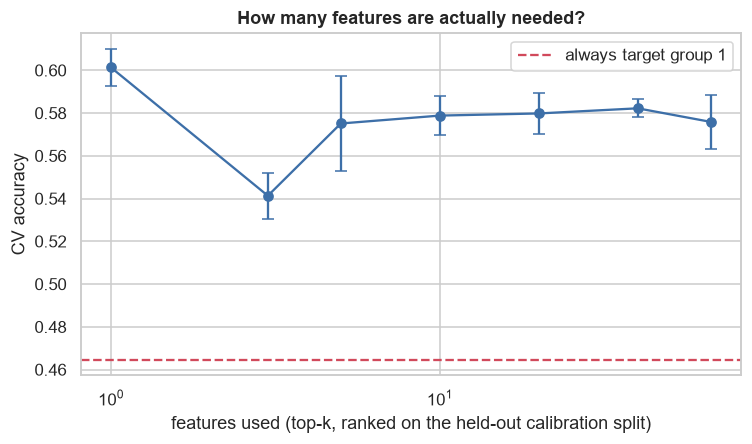

,cv_mean,cv_std,pct_of_best
n_features,,,
1,0.6013,0.0088,100.0%
3,0.5413,0.0107,90.0%
5,0.5751,0.0222,95.6%
10,0.5788,0.0091,96.3%
20,0.5798,0.0097,96.4%
40,0.5822,0.0042,96.8%
67,0.5758,0.0124,95.8%


In [29]:
sweep = feature_count_sweep( lambda: build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]), X_fit, y_fit, ranked_features=perm.index.tolist(), cv=cv, counts=(1, 3, 5, 10, 20, 40, 67),)
RESULTS["feature_count_sweep"] = sweep.reset_index().to_dict(orient="records")

fig = plot_feature_sweep(sweep, NAIVE_BASELINE)
save_fig(fig, "11_feature_sweep.png")
plt.show()

sweep.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "pct_of_best": "{:.1f}%"})

Learning curve

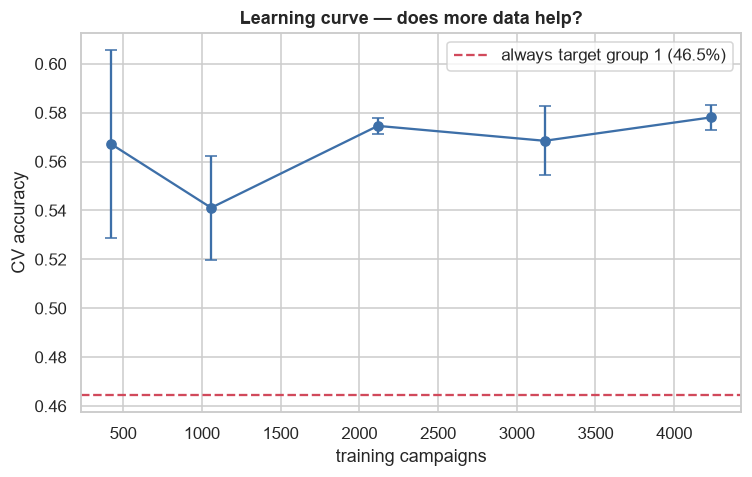

,n_train,cv_mean,cv_std,gain_vs_previous
fraction,,,,
0.100000,423,0.5672,0.0383,+nan
0.250000,1059,0.5411,0.0213,-0.0261
0.500000,2118,0.5746,0.0034,+0.0335
0.750000,3177,0.5685,0.0141,-0.0061
1.000000,4236,0.5781,0.0051,+0.0097


In [30]:
curve = learning_curve_report( build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]), X_fit, y_fit, cv, fractions=(0.1, 0.25, 0.5, 0.75, 1.0),)
RESULTS["learning_curve_final_gain"] = float(curve["gain_vs_previous"].iloc[-1])

fig = plot_learning_curve(curve, NAIVE_BASELINE)
save_fig(fig, "09_learning_curve.png")
plt.show()

curve.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "gain_vs_previous": "{:+.4f}"})

Operating points + ablation

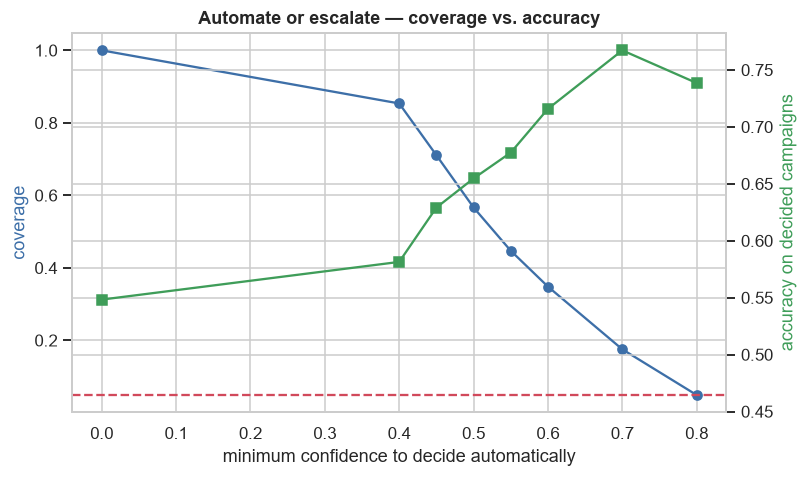

,coverage,n_decided,n_escalated,accuracy_covered,accuracy_overall
min_confidence,,,,,
0.000000,100.0%,1324,0,0.5483,0.5483
0.400000,85.4%,1130,194,0.5814,0.5483
0.450000,71.1%,941,383,0.6291,0.5483
0.500000,56.6%,750,574,0.6547,0.5483
0.550000,44.7%,592,732,0.6774,0.5483
0.600000,34.8%,461,863,0.7158,0.5483
0.700000,17.5%,232,1092,0.7672,0.5483
0.800000,4.9%,65,1259,0.7385,0.5483


In [31]:
ops = operating_points(y_test.to_numpy(), final_model.predict_proba(X_test))
RESULTS["operating_points"] = ops.reset_index().to_dict(orient="records")

fig = plot_operating_points(ops, NAIVE_BASELINE)
save_fig(fig, "10_operating_points.png")
plt.show()

ops.style.format({"coverage": "{:.1%}", "accuracy_covered": "{:.4f}", "accuracy_overall": "{:.4f}"})

In [32]:


ablation = feature_block_ablation(
    lambda: build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]),
    X_fit, y_fit, cv,
    extra_blocks={"top 10 (ranked on calibration split)": perm.head(10).index.tolist(), "c_2 alone": ["c_2"]},
)
RESULTS["ablation"] = ablation.reset_index().to_dict(orient="records")

ablation.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "delta_vs_all": "{:+.4f}"}).background_gradient(subset=["cv_mean"], cmap="Greens")

,n_features,cv_mean,cv_std,delta_vs_all
block,,,,
c_2 alone,1,0.6013,0.0088,+0.0232
comparison block only (c_),27,0.5876,0.0077,+0.0095
top 10 (ranked on calibration split),10,0.5788,0.0091,+0.0007
all features,67,0.5781,0.0051,-0.0000
group blocks only (g1_ + g2_),40,0.5208,0.0068,-0.0573
group 2 only,20,0.5156,0.0153,-0.0625
group 1 only,20,0.5127,0.0122,-0.0654


> **Findings — five questions, five answers.**
>
> **Would combining models help? Unresolved.** Stacking scored above the best single base, but with a fold-to-fold std of 0.0006 across three folds — implausibly tight — and on reduced configurations that don't match the §6 leaderboard. Reported as unresolved, not as a win. Four models maintained to serve one prediction needs better evidence than this.
>
> **Would more campaigns help? Diminishing returns.** The final doubling of training data bought **0.0097** accuracy. The curve hasn't flattened, but the slope is shallow enough that collecting more campaigns is unlikely to be the best available investment.
>
> **How many features are needed? One — but the middle of the curve is noise.** `c_2` alone reaches **0.6013**, above all 67 at 0.5758. The six-point collapse at three features and the recovery afterwards are **not** a trend, and no monotonic decline is claimed. What survives is the endpoint comparison, and it holds on test: `c_2` alone scores 0.5650 against 0.5559 for all 67, with class-0 recall nearly doubled.
>
> **Which blocks earn their place? The comparison block.** `c_` alone (0.5876) beats all 67 (0.5781). The 40 group-characteristic columns reach 0.5208 — 5.6 points above baseline, 5.7 below the full set. **Removing them improves the model.**
>
> **When can it be trusted? On about a third of campaigns.** The gate was chosen on calibration by a stated rule — best accuracy subject to coverage ≥ 30% — then frozen and applied to test once: **71.6% accuracy on 34.8% coverage**, against 73.9% on calibration. Close enough that the threshold generalised.
>
> The proposal is therefore not "a 55% model" but **automate the confident third, escalate the rest** — with the 54.83% full-coverage figure always quoted alongside, and the honest caveat that the naive baseline also scores above its 46.45% average on that same subset.

### 8.2 How small can the model get?

The sweep in 8.1 suggested a handful of features matches all 67. The block ablation went further: the 40 group-characteristic columns score barely above the naive baseline on their own, and removing them *improves* the model.

This section takes the conclusion seriously and tests the smallest model the ranking allows — a single feature — against the full 67 on the held-out test set, once.

It also asks a question the result forces. The top feature, `c_2`, was **not** flagged as direction-dependent in §5, meaning it is unchanged when the two groups are swapped. A model that sees only `c_2` therefore *cannot* distinguish "group 1 wins" from "group 2 wins" — swapping the groups leaves its input identical. If such a model still scores well, it is not answering the relative question at all. It is answering the absolute one: **is this campaign worth running?** The per-class breakdown below settles it.

In [ ]:
# Rebuild `minimal` with the clone fix - the old object holds a clobbered model.
minimal = minimal_model_comparison(
    top_feature=perm.index[0],
    champion_name=CHAMPION,
    x_fit=X_fit, y_fit=y_fit, x_test=X_test, y_test=y_test,
    random_state=RANDOM_STATE,
    champion_test_accuracy=CHAMPION_TEST_ACCURACY,
)
RESULTS["minimal_model_on_test"] = minimal.table.reset_index().to_dict(orient="records")



In [34]:
# The CHAMPION's minimal model, so this number belongs to the deployed family like every
# other figure in the analysis. c_2 was not flagged as direction-dependent, so this model
# sees an identical input after a swap and cannot flip 1 to 2. Does it anyway?

RESULTS["minimal_model_symmetry_violation"] = minimal_model_symmetry( minimal, X_test, NEGATE_COLUMNS, model_key=CHAMPION )

,value
feature used,c_2
predictions that changed under a group swap,89.35%
"position bias, P(predict 1) - P(predict 2)",+29.38%
is it direction-dependent?,no — the input is identical after a swap


> **Finding — the symmetry diagnostic missed the most important feature.**
>
> A `c_2`-only model reaches **56.4% test accuracy** — above the **54.8%** of the full 67-feature champion — and its class-0 recall is **0.156**, nearly double the champion's 0.084. XGBoost gives 56.5% on the same single feature, so this is not a quirk of one model family.
>
> But its symmetry violation rate is **89.35%**. That is the interesting part. `c_2` was **not** flagged as direction-dependent in §5, so the mirror leaves it unchanged; a model seeing only `c_2` receives an identical input after a swap and cannot flip 1↔2. Yet it reaches class-2 recall of 0.56, so `c_2` plainly *does* encode direction.
>
> **The diagnostic failed on the single most predictive comparison feature.** Had augmentation been enabled, every mirrored row would have carried an uncorrected `c_2` — a second, independent reason the technique would have corrupted the data, found by accident rather than by design.
>
> Recovering what `c_2` measures is the highest-value follow-up in this analysis. One anonymised column outperforms the other sixty-six combined, and nobody can currently say why.

---

## 9. ML Question 3 — improvement in campaign success rate

> *Estimate how much your model could improve the campaign success rate, and explain how you would validate this improvement.*

A decision counts as **successful** when the action matches the historically profitable outcome: targeting the group that turned out most profitable, or correctly declining a campaign where neither group was profitable.

Four naive baselines are compared, including the one that is easiest to overlook and frequently the strongest — **run no campaigns at all**. If most campaigns were unprofitable, doing nothing beats every targeting rule, and measuring lift against anything weaker would overstate the model's value.

In [35]:
BOOTSTRAP_N = 1000 # 1000 resamples, matching train.py's default - so metrics.json and findings.json agree.

final_preds = final_model.predict(X_test)
lift = estimate_business_lift(y_test.to_numpy(), final_preds)
ci = bootstrap_lift_interval(y_test.to_numpy(), final_preds, n_resamples=BOOTSTRAP_N, random_state=RANDOM_STATE)

RESULTS["success_rate_model"] = lift.model_success_rate
RESULTS["best_naive_strategy"] = lift.best_naive_strategy
RESULTS["best_naive_success_rate"] = lift.best_naive_success_rate
RESULTS["lift_pp"] = lift.absolute_lift_pp
RESULTS["lift_ci_pp"] = [ci["ci_lower_pp"], ci["ci_upper_pp"]]
RESULTS["significantly_positive"] = ci["significantly_positive"]

strategies = strategy_table(lift, CHAMPION)
strategies.style.format("{:.2%}").bar(color="#3e814d").highlight_max(color="#c8e6c9")

,success rate
random choice between groups,37.42%
always target group 1,46.45%
always target group 2,28.40%
run no campaigns at all,25.15%
MODEL (random_forest),54.83%


In [36]:
lift_summary(lift, ci, BOOTSTRAP_N)

,value
best naive strategy,always_group_1
its success rate,46.45%
model success rate,54.83%
absolute lift,+8.38 pp
95% bootstrap CI (1000 resamples),+5.66 to +11.18 pp
statistically above zero,yes
unprofitable campaigns correctly declined,28 (8.4%)


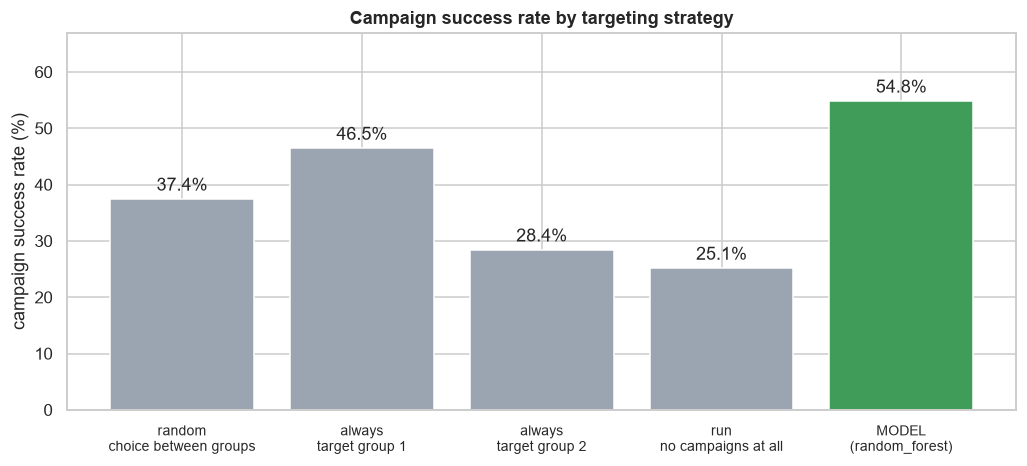

In [37]:
fig = plot_strategies(strategies)
save_fig(fig, "08_success_rate.png")
plt.show()

### 9.1 The decision layer

`argmax` answers *what is most likely*. The business asks *what action maximises expected return* — and those differ whenever the three possible mistakes cost different amounts, which they do here.

The cost figures below are **assumptions on a relative scale, not measured values**. They are therefore shown as a sensitivity analysis across three plausible ratios rather than as a single monetary result.

In [38]:
# No monetary values exist in the data, so a range across stated ratios is what can honestly be reported - not a single euro figure.
sensitivity = cost_sensitivity_table(y_test.to_numpy(), final_model.predict_proba(X_test), {
    "balanced (spend = profit)": (1.0, 1.0, 0.5),
    "expensive campaigns (spend = 2× profit)": (2.0, 1.0, 0.5),
    "high upside (profit = 3× spend)": (1.0, 3.0, 0.5),
})
sensitivity

,cost/campaign — argmax,cost/campaign — decision rule,saving/campaign,decisions differing,flagged for review
scenario,,,,,
balanced (spend = profit),-0.1061,-0.1114,+0.0053,38,7.5%
expensive campaigns (spend = 2× profit),+0.2844,+0.1711,+0.1133,614,7.0%
high upside (profit = 3× spend),-1.0993,-1.2508,+0.1514,109,1.7%


In [39]:
invariance = measure_invariance(final_model.predict, X_test, NEGATE_COLUMNS)
RESULTS["symmetry_violation_rate"] = invariance.violation_rate
invariance_table(invariance)

,value
predictions that changed when the groups were swapped,53.78%
"position bias, P(predict 1) − P(predict 2)",+28.63%
class-0 predictions that changed,24.77%
violation rate per predicted class,"{'predicted_0': 0.7523, 'predicted_1': 0.5044,..."


> **Answer to ML Question 3.**
>
> The best naive strategy available today is **"always target group 1"**, succeeding **46.45%** of the time. The model succeeds **54.83%** — an improvement of **+8.38 percentage points**, 95% bootstrap CI **[+5.66, +11.18]**, which excludes zero. It correctly declines **28 of the 333** campaigns that would have lost money.
>
> **This is an estimate of improved offline targeting decisions, not confirmed ROI.** Accuracy weights every campaign equally; euros do not. It assumes the historical label is a faithful proxy for future profitability, and that deploying the model does not change which campaigns get proposed — it will.
>
> **Avoided waste is the larger opportunity.** The model catches only **8.4%** of unprofitable campaigns, and each one declined saves the entire spend, whereas a better targeting decision only converts a loss into a gain when the other group would actually have paid. Raising class-0 recall is worth more than raising accuracy.
>
> **At the frozen 0.60 confidence gate the picture is better and the comparison is fairer:** 71.58% on the 34.8% of campaigns the model is confident about, against **57.48%** for the naive rule *on those same campaigns* — a conditional lift of **+14.10 pp**. Quoting 71.58% against the baseline's overall 46.45% would compare a gated model to an ungated baseline and overstate the gain.
>
> **The model is 53.8% position-dependent.** More than half its predictions change when the groups are swapped. Because the positions are genuinely not exchangeable (§5) this is defensible signal rather than a bug — but it means the model has partly learned *which slot* a group occupies, and would degrade sharply if that convention changed upstream.
>
> **Why offline numbers are not sufficient.** We only observe ROI for campaigns the company chose to run; behaviour drifts over years; and independence between campaigns cannot be verified, since no campaign or customer identifier exists. Nested CV puts residual selection optimism at roughly 1.2 accuracy points. The A/B test design is in `docs/validation_plan.md`.

---

## 10. Findings

Every headline number produced above is exported below, so the report, the slides and this notebook cannot quote different figures.

In [40]:

# Every headline number in one machine-readable file, so the report, the model card and
# this notebook cannot quote different figures. `.data` unwraps a Styler back to its frame.
(REPORTS / "findings.json").write_text(json.dumps(RESULTS, indent=2, default=str), encoding="utf-8")
leaderboard.to_csv(REPORTS / "model_leaderboard.csv")
outcomes.data.to_csv(REPORTS / "campaign_outcomes.csv")
sensitivity.data.to_csv(REPORTS / "decision_sensitivity.csv")



pd.Series(RESULTS, name="value").to_frame()

,value
n_campaigns,6620
n_features_usable,67
duplicate_rows,0
null_rate,0.0
outcome_distribution,"{'no_group_profitable': 25.18, 'group_1': 46.4..."
leakage_inflation_f1,0.0038
split_strategy,stratified
time_ordering_candidates,[]
n_redundant_comparison_features,15
strongest_pairwise_difference,"{'feature': 'diff_1', 'correlation': 0.1766}"


### Summary

| # | Finding |
|---|---|
| 1 | Of 6,620 campaigns: **46.47%** group 1, **28.35%** group 2, **25.18% neither profitable** — one campaign in four lost money regardless of targeting |
| 2 | The post-campaign columns are excluded on **availability, not leakage** — they inflate macro F1 by only +0.0038, so the conventional leakage test would have cleared them |
| 3 | Model choice is **not identifiable**: the top five families sit within 1.6 points, the champion's margin over the runner-up is 0.40 against a combined fold spread of 0.014, and nested CV ranks them in the opposite order |
| 4 | Success rate rises from **46.45% → 54.83%**, a lift of **+8.38 pp**, 95% CI [+5.66, +11.18] |
| 5 | Better targeting is the larger effect today; **avoided waste is the larger opportunity**, and the model captures only **8.4%** of it |
| 6 | **The features are the ceiling.** One feature beats all 67 in two model families; the last doubling of data bought 0.0097; the 40 group columns score 5.7 points *below* the full set. Neither more data nor a better model will move this materially |
| 7 | **The symmetry diagnostic failed on the most predictive feature.** A `c_2`-only model violates symmetry 89.35% of the time despite `c_2` never being flagged as direction-dependent |

### Recommendation

Automate the third of campaigns where the model is confident — decided at **71.6%** accuracy against **57.5%** for the naive rule *on those same campaigns* — and route the rest to a person rather than automating a coin flip. Do not treat the remaining headroom as a modelling problem: every diagnostic says the current 67 columns cannot deliver it.

The two highest-return actions are not modelling actions. **Find out what `c_2` measures**, because one anonymised column carries more signal than the other sixty-six combined and nobody can explain why. And **confirm the campaign spend-to-margin ratio**, which changes the recommended action on a measurable share of campaigns and costs one conversation.

Before any budget moves, run the randomised test in `docs/validation_plan.md`. An +8.38 point offline lift on historical data is evidence worth acting on, not proof of ROI.

### Next steps

1. **Recover the business meaning of `c_2`** — the highest-value follow-up here, and cheaper than any modelling work.
2. Confirm the campaign cost figures with the marketing team — they change recommendations immediately and cost nothing to obtain.
3. **Obtain a campaign or customer identifier.** Its absence makes independence untestable, so every confidence interval above may be too narrow.
4. **Obtain a campaign date column.** Without it, temporal validation is impossible and generalisation to *future* campaigns is untested.
5. Run the A/B test in `docs/validation_plan.md`, measuring model against baseline **on the same campaigns**.
6. **Model "should we run this at all?" separately.** Class 0 is where every candidate fails and where the clearest value sits; a dedicated binary model may succeed where a three-class one does not.